In [1]:
import numpy as np
import sympy as sp
import time as time
import matplotlib.pyplot as plt
import pandas as pd

"""
Las funciones se definen en sympy con x e y, para facilitar que sean iguales en todos los codigos
"""

'\nLas funciones se definen en sympy con x e y, para facilitar que sean iguales en todos los codigos\n'

# Órbitas de Kepler

Para empezar a tratar el problema de Kepler, vamos a definir un par de métodos de resolución de EDOs de manera escalar, y conociendo sus errores y su rendimiento seleccionar uno, que será adapatado a las funciones vectoriales para seguir con la resolución del problema

In [2]:
# Esta funcion sirve para resolver EDO conociendo las condiciones iniciales, y la vamos a usar para el cálculo de errores
def EDO(f,x0,y0):
    # Estas funciones hacen que y se convierta en y(x), cambio fundamental para utilizar sp.dsolve
    y_dsolve = sp.Function('y')(x)
    f_dsolve = f.subs(y,y_dsolve)
    # Aquí se obtiene la solucion de la EDO y se utiliza un diccionario para implementar las condiciones iniciales
    edo = sp.Eq(sp.Derivative(y_dsolve, x), f_dsolve)
    condicion_inicial = {y_dsolve.subs(x, x0): y0}
    solucion = sp.dsolve(edo, y_dsolve, ics=condicion_inicial)
    # .rhs sirve para que la funcion devuelva la solucion recortada en vez de un elemento matematico resultado de sp.dsolve
    return solucion.rhs

"""
    -----PRUEBA-----
"""
x = sp.symbols('x')
y = sp.symbols('y')
x0 = 0
y0 = 1
f = x + y
print (EDO(f,x0,y0))

-x + 2*exp(x) - 1


## Método de Euler

Este método se utiliza para resolver ecuaciones diferenciales de orden 1, es decir, de esta forma:

$$\frac{dy}{dt} = t^2 - y$$

El proceso consiste en a partir de la pendiente en un punto inicial, estimar el valor de y en un punto x + h y alli calcular su pendiente para repetir el proceso n veces hasta el valor de y buscado

In [3]:
def Euler(f,x0,y0,n,xf):
    n = int(n)
    x,y = sp.symbols('x y')
    # f es una funcion sympy de variables de la forma dy/dx(x,y). x0 e y0 son los valores de los que se parte en dichas variables
    # n es el numero de particiones que se estudiaran en el intervalo x0-xf y xf es el valor final de x.
    h = (xf-x0)/n
    # h es lo que mide cada trozo de la particion de [x0,xf] realizada n veces
    x_array = np.zeros(n+1)
    y_array = np.zeros(n+1)
    x_array[0] = x0
    y_array[0] = y0
    """
    Este for va evaluando la funcion dy/dx(x,y) empezando en los valores iniciales y va dando valor
    a todos los siguientes valores de x e y hasta llegar al xf
    """
    for i in range(n):
        evaluado = f.subs([(x,x_array[i]),(y,y_array[i])])
        x_array[i+1] = x_array[i] + h
        y_array[i+1] = y_array[i] + h*evaluado
    
    return y_array
    
    

In [4]:
# Cálculo del error que comete este método en comparacion a la solucion real de la EDO.
# Este error varía dependiendo del numero de particiones que se haga, es decir, el valor de n
def error_Euler(f,x0,y0,n,xf):
    # solx y soly son los array resultante de la funcion Euler y sol_real es la solucion analitica de la EDO
    sol = Euler(f,x0,y0,n,xf)
    sol_real = EDO(f,x0,y0)
    # y_real es el valor de la solucion analitica en x = xf
    y_real = sol_real.subs(x,xf)
    error = float(np.abs((sol[n]-y_real)/y_real)*100)
    return error
    

# Método de Runge-Kutta

Este método sirve para encontrar valores del mismo estilo de los que es capaz de encontrar el método de Euler.

Vamos a usar especificamente el Método de Runge-Kutta de cuarto orden, que llamaremos RK4

Recibe un valor inicial x y un valor de x para el que se busca la y que le corresponde. En ese intervalo formado se calculan:
- k1, la pendiente en el punto inicial
- k2 y k3, pendientes en el punto medio, la segunda mejor estimada a partir del valor que tome la primera
- k4, la pendiente estimada en el punto final

Finalmente se aproxima el valor de y en el final del intervalo mediante esta ecuación:

$$y_{1} = y_0 + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)$$

(Siendo y1 el valor de y al final del intervalo, y0 el valor inicial de y, h la longitud del intervalo estudiado)

In [5]:
def RK4(f,x0,y0,xf):
    x,y = sp.symbols('x y')
    # Cálculo de h
    h = xf - x0
    # Cálculo de las pendientes indicadas en la descripción del método
    k1 = f.subs([(x,x0),(y,y0)])
    k2 = f.subs([(x,x0 + (1/2)*h),
                 (y,y0 + (1/2)*k1*h)])
    k3 = f.subs([(x,x0 + (1/2)*h),
                 (y,y0 + (1/2)*k2*h)])
    k4 = f.subs([(x,x0 + h),(y,y0 + k3*h)])
    # Aplicación de la ecuacion del RK4
    solucion = y0 + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
    return solucion

    

In [6]:
# Este cálculo del error sigue el mismo procedimiento que el del método de Euler
def error_RK4(f,x0,y0,xf):
    sol = RK4(f,x0,y0,xf)
    sol_real = EDO(f,x0,y0)
    y_real = sol_real.subs(x,xf)
    error = error = float(np.abs((sol-y_real)/y_real)*100)
    return error

# Comparación

Aquí es para poner la comparacion de los errores numéricos de los métodos anteriores que no tienen por que ser solo esos 2 y luego con la libreria time hacer una comparacion del tiempo que tarde el ordenador en ejecutarlos

In [7]:
# Datos de prueba
x,y = sp.symbols('x y')
x0 = 0
xf = 1
y0 = 1
n = 15
f = x + y

In [8]:
lista = []
for i in range(2,102,2):
    lista.append(error_Euler(f,x0,y0,i,xf))
x_graf = np.linspace(2,100,50)
y_graf = lista


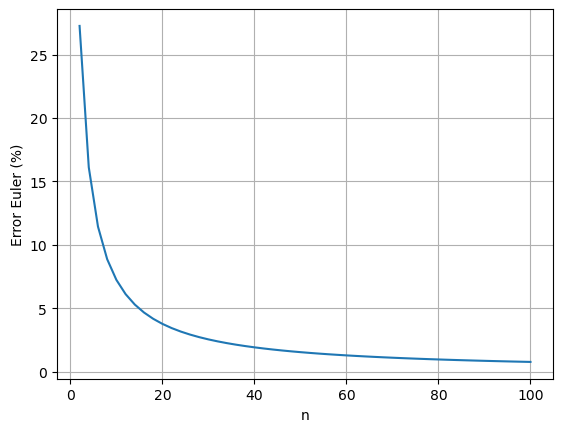

In [9]:
fig,ax = plt.subplots()
ax.plot(x_graf,y_graf)
ax.set_xlabel('n')
ax.set_ylabel('Error Euler (%)')
plt.grid()
plt.show()

In [10]:
print(f'Con estos datos de prueba, el error cometido por el método de Euler es de un {error_Euler(f,x0,y0,n,xf)}%')
print(f'Con estos datos de prueba, el error cometido por el método RK4 es de un {error_RK4(f,x0,y0,xf)}%')

Con estos datos de prueba, el error cometido por el método de Euler es de un 4.970262113969745%
Con estos datos de prueba, el error cometido por el método RK4 es de un 0.5789792431567531%


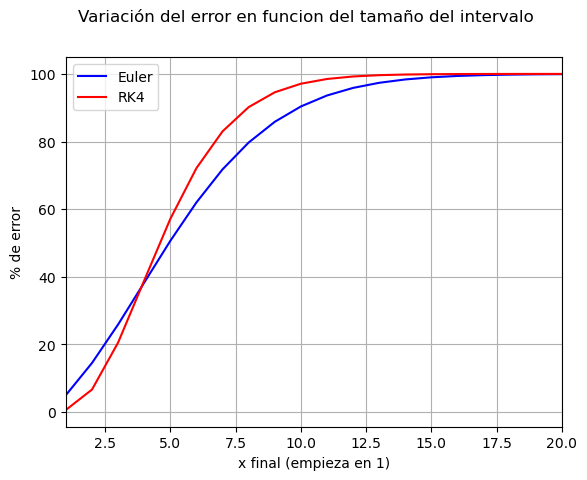

In [11]:
lista_1 = []
lista_2 = []
for i in range(1,21):
    lista_1.append(error_Euler(f,x0,y0,n,i))
    lista_2.append(error_RK4(f,x0,y0,i))
fig,ax = plt.subplots()
x_graf = np.array([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20])
y_graf = lista_1
z_graf = lista_2
ax.plot(x_graf,y_graf, color='b', label = 'Euler')
ax.plot(x_graf,z_graf, color='r', label = 'RK4')
plt.legend()
ax.set_xlabel('x final (empieza en 1)')
ax.set_ylabel('% de error')
ax.set_xlim(1,20)
fig.suptitle('Variación del error en funcion del tamaño del intervalo')
plt.grid()
plt.show()


#### Usando la librería time se puede comparar el tiempo que tardan en ejecutarse ambos métodos, aunque dependerá del dispositivo y del numero de divisiones utilizadas para el método de Euler

In [12]:
t0 = time.perf_counter()
Euler_1 = Euler(f,x0,y0,n,xf)
tf = time.perf_counter()
t_Euler = tf-t0
t0 = time.perf_counter()
RK4_1 = RK4(f,x0,y0,xf)
tf = time.perf_counter()
t_RK4 = tf-t0
print(f'Con estos datos de prueba, el tiempo que ha necesitado método de Euler es {t_Euler} segundos')
print(f'Con estos datos de prueba, el tiempo que ha necesitado método RK4 es {t_RK4} segundos')

Con estos datos de prueba, el tiempo que ha necesitado método de Euler es 0.011469000019133091 segundos
Con estos datos de prueba, el tiempo que ha necesitado método RK4 es 0.0015189999830909073 segundos


# El problema de Kepler

Aquí aproximaremos las ecuaciones diferenciales que describen el movimiento de los planetas en sus órbitas

Para ello utilizaremos el método RK4 explicado antes, pero para comenzar a resolver las ecuaciones necesarias hay que adaptarlo a funciones vectoriales de dos dimenisiones y EDOs de segundo orden.

La funcion va a estar definida con vectores de Numpy para facilitar el manejo de todas las variables

Las variables a estudiar van a estar organizadas en un vector llamado vector de estado, que en nuestro caso tendrá la siguiente forma:

$$ Y = (x, y, vx, vy) $$

Aquí estan contenidas las componentes en los dos ejes de la posición y de la velocidad.

Para simplificar el problema a una EDO de primer orden que podamos resolver con este método introducimos un nuevo vector, el vector de derivadas, que en nuestro caso tendrá esta forma:

$$ F = (\frac{dx}{dt},\frac{dy}{dt},\frac{dvx}{dt},\frac{dvy}{dt})$$
$$ F = (vx,vy,ax,ay)$$

La nueva EDO, que será la que vamos a resolver, tendrá la siguiente forma:

$$\frac{dY}{dt} = F(t, Y)$$

### Para empezar con el método hay que definir una función, diferente para cada EDO, que nos permite hacer el cambio entre Y y F:

La función seguira la EDO de segundo orden de la gravitación de Newton

$$m_1 \frac{d^2r}{dt^2} = -G \frac{m_1 m_2}{r^2} \hat{r}$$

$$ \frac{d^2\mathbf{r}}{dt^2} = -G \frac{m_2}{r^2} \hat{\mathbf{r}}$$

Aunque en este caso el tiempo no participe en la función, t aparecerá como argumento en la función, lo que servirá para poder generalizar el RK4 mas fácilmente

In [13]:
# Esta función nos permite conocer F unicamente para problemas de orbitas gravitatorias
def func(t,Y, G, M):
    x, y, vx, vy = Y
    r = np.sqrt(x**2+y**2)
    a = -(G*M)/r**2
    # Podemos calcular las componentes gracias al conocer r, x e y
    ax = a * (x/r)
    ay = a * (y/r)
    F = [vx,vy,ax,ay]
    return np.array(F)

In [14]:
def RK4_vec(func,h,Y0, t,G,M):
    # func es la funcion de antes, h es la distacia del intervalo y Y0 es el vector de variables iniciales
    # Aparecen formulas nuevas respecto a las de RK4 para escalares que tienen la h fuera de la función
    k1 = h * func(t, Y0,G,M)
    k2 = h * func(t + h/2, Y0 + k1/2,G,M)
    k3 = h * func(t + h/2, Y0 + k2/2,G,M)
    k4 = h * func(t + h, Y0 + k3,G,M)
    # También cambia la formula final
    Y1 = Y0 + 1/6 * (k1 + 2*k2 + 2*k3 + k4)
    return Y1

# Energía total, momento angular y excentricidad

En el caso de unos cálculos ideales, la energía tota y el momento angular se nmantienen constantes, lo que nos permite calcular la excentricidad de la órbita y determinar gracias a ella su forma

In [15]:
G = 6.67430e-11  # Constante de gravitación universal

# ENERGÍA TOTAL (por unidad de masa si no se da masa)

def energia_total(r, v, M, m=1):
    """
        Parámetros:
        r : vector de posición
        v : vector de velocidad 
        M : masa del cuerpo central
        m : masa del cuerpo orbitante (por defecto 1)
    """
    r = np.array(r)
    v = np.array(v)
    r_norm = np.linalg.norm(r)
    v_norm = np.linalg.norm(v)

    K = 0.5 * m * v_norm**2
    U = - G * M * m / r_norm

    return K + U




# MOMENTO ANGULAR

def momento_angular(r, v, m=1):
    """
    Calcula el vector de momento angular L = m * r × v.
    """
    r = np.array(r)
    v = np.array(v)
    return m * np.cross(r, v)




# EXCENTRICIDAD

def excentricidad_vector(r, v, M):
    """
    Calcula el vector de excentricidad e en 2D extendido a 3D para np.cross
    """
    r = np.array(r, dtype=float)
    v = np.array(v, dtype=float)

    r3 = np.array([r[0], r[1], 0.0])
    v3 = np.array([v[0], v[1], 0.0])

    r_norm = np.linalg.norm(r3)
    h3 = np.cross(r3, v3)
    e_vec3 = (np.cross(v3, h3) / (G * M)) - (r3 / r_norm)
    return np.array([e_vec3[0], e_vec3[1]])





# EXCENTRICIDAD ESCALAR

def excentricidad(r, v, M):
    excenticidad_final = np.linalg.norm(excentricidad_vector(r, v, M))

    if excenticidad_final == 0:
        return 'Describe una circunferencia'
    
    if 0 < excenticidad_final < 1:
        return 'Describe una elipse'
    
    if excenticidad_final == 1:
        return 'Describe una parábola'
    
    if excenticidad_final > 1:
        return 'Describe una hipérbola'
    
    return excenticidad_final


# ---------------------------------------------------------
# IMPRESIÓN RÁPIDA DE TODO
# ---------------------------------------------------------
def resumen_orbital(r, v, M, m=1):
    print("-----------------------------------------")
    print("   RESUMEN DE MAGNITUDES ORBITALES")
    print("-----------------------------------------")

    E = energia_total(r, v, M, m)
    L = momento_angular(r, v, m)
    e_vec = excentricidad_vector(r, v, M)
    e = np.linalg.norm(e_vec)

    print(f"Energía total = {E}")
    print(f"Momento angular L = {L}")
    print(f"Vector de excentricidad e = {e_vec}")
    print(f"Excentricidad = {e}")
    print("-----------------------------------------")

# Ejemplo rápido (puedes borrar)
if __name__ == "__main__":
    r0 = [1, 0, 0]
    v0 = [0, 1, 0]
    M0 = 5.972e24
    resumen_orbital(r0, v0, M0)

-----------------------------------------
   RESUMEN DE MAGNITUDES ORBITALES
-----------------------------------------
Energía total = -398589195999999.5
Momento angular L = [0 0 1]
Vector de excentricidad e = [-1.  0.]
Excentricidad = 0.9999999999999974
-----------------------------------------


# Funciones de la posicion y la velocidad en función del tiempo

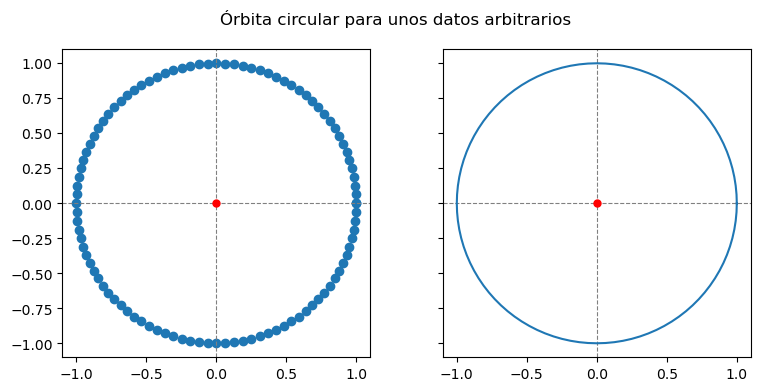

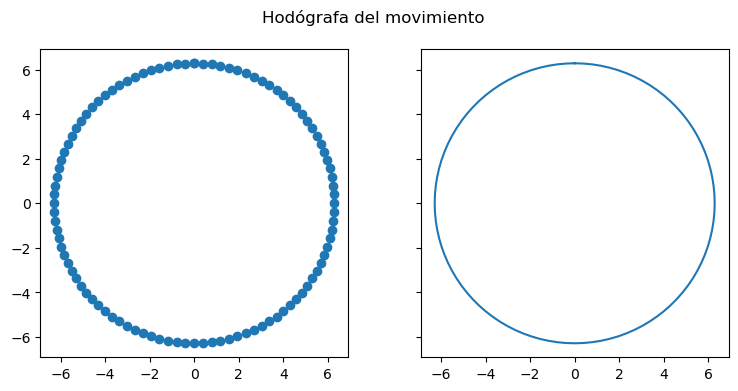

In [16]:
t = 1
n = 100
G = 4
M = np.pi**2
Y0 = np.array([1,0,0,2*np.pi])
x_lista = [1]
y_lista = [0]
vx_lista = [0]
vy_lista = [2*np.pi]
for i in range(n):
    a = RK4_vec(func,0.01,Y0,t,G,M)
    x_lista.append(a[0])
    y_lista.append(a[1])
    vx_lista.append(a[2])
    vy_lista.append(a[3])
    Y0 = a
fig,axs = plt.subplots(1,2, sharey = True, figsize = (9,4))
axs[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axs[0].axvline(0, color='gray', linestyle='--', linewidth=0.8)
axs[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axs[1].axvline(0, color='gray', linestyle='--', linewidth=0.8)
axs[0].plot(0, 0, 'o', color='red', markersize=5, label='Origen')
axs[1].plot(0, 0, 'o', color='red', markersize=5, label='Origen')
axs[0].scatter(x_lista,y_lista)
axs[1].plot(x_lista,y_lista)
axs[0].set_aspect('equal')
axs[1].set_aspect('equal')
plt.suptitle('Órbita circular para unos datos arbitrarios')
plt.show()
fig,axs = plt.subplots(1,2, sharey = True, figsize = (9,4))
axs[0].scatter(vx_lista,vy_lista)
axs[1].plot(vx_lista,vy_lista)
axs[0].set_aspect('equal')
axs[1].set_aspect('equal')
plt.suptitle('Hodógrafa del movimiento')
plt.show()



# Órbita circular

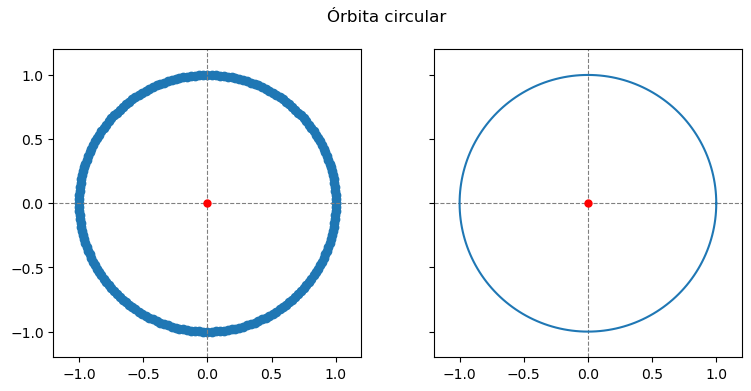

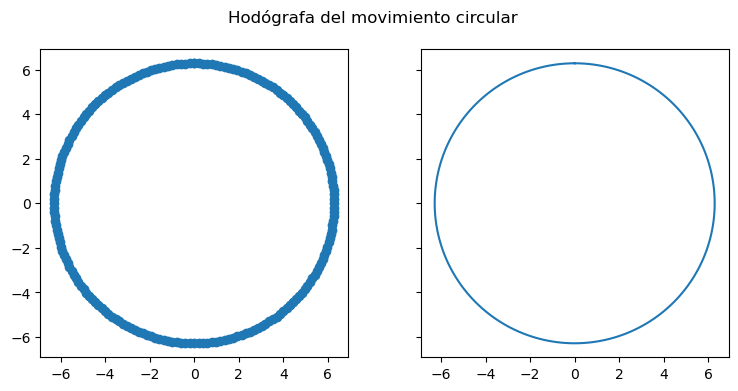

In [17]:
t = 1
n = 200
G = 4
M = np.pi**2
Y0 = np.array([1,0,0,2*np.pi])   # v_y = velocidad circular
x_lista = [1]
y_lista = [0]
vx_lista = [0]
vy_lista = [2*np.pi]

for i in range(n):
    a = RK4_vec(func,0.005,Y0,t,G,M)
    x_lista.append(a[0])
    y_lista.append(a[1])
    vx_lista.append(a[2])
    vy_lista.append(a[3])
    Y0 = a

# --- gráficas de órbita ---
fig,axs = plt.subplots(1,2, sharey = True, figsize = (9,4))
axs[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axs[0].axvline(0, color='gray', linestyle='--', linewidth=0.8)
axs[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axs[1].axvline(0, color='gray', linestyle='--', linewidth=0.8)

axs[0].plot(0, 0, 'o', color='red', markersize=5, label='Origen')
axs[1].plot(0, 0, 'o', color='red', markersize=5, label='Origen')

axs[0].scatter(x_lista,y_lista)
axs[1].plot(x_lista,y_lista)

axs[0].set_aspect('equal')
axs[1].set_aspect('equal')
axs[0].set_xlim(-1.2,1.2)
axs[0].set_ylim(-1.2,1.2)
axs[1].set_xlim(-1.2,1.2)
axs[1].set_ylim(-1.2,1.2)

plt.suptitle('Órbita circular')
plt.show()

# --- hodógrafa ---
fig,axs = plt.subplots(1,2, sharey = True, figsize = (9,4))
axs[0].scatter(vx_lista,vy_lista)
axs[1].plot(vx_lista,vy_lista)
axs[0].set_aspect('equal')
axs[1].set_aspect('equal')
plt.suptitle('Hodógrafa del movimiento circular')
plt.show()


# Órbita elíptica

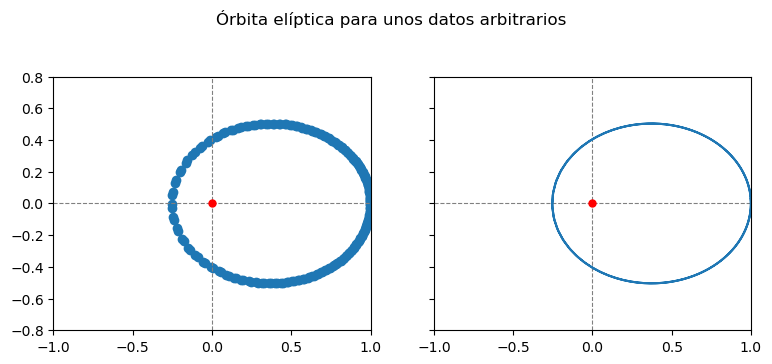

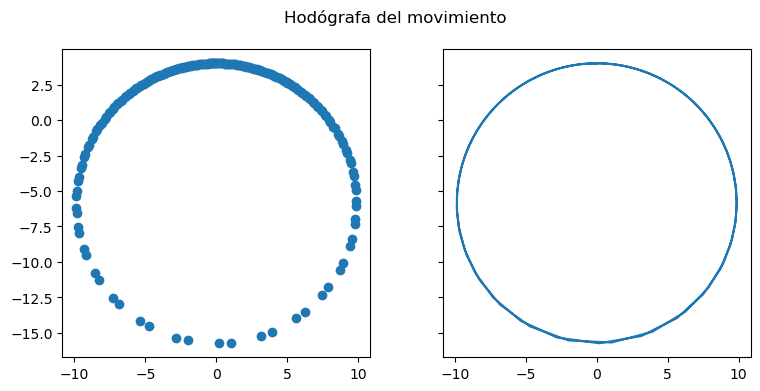

In [18]:
t = 1
n = 200
G = 4
M = np.pi**2
Y0 = np.array([1,0,0,4])
x_lista = [1]
y_lista = [0]
vx_lista = [0]
vy_lista = [4]
for i in range(n):
    a = RK4_vec(func,0.005,Y0,t,G,M)
    x_lista.append(a[0])
    y_lista.append(a[1])
    vx_lista.append(a[2])
    vy_lista.append(a[3])
    Y0 = a
fig,axs = plt.subplots(1,2, sharey = True, figsize = (9,4))
axs[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axs[0].axvline(0, color='gray', linestyle='--', linewidth=0.8)
axs[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axs[1].axvline(0, color='gray', linestyle='--', linewidth=0.8)
axs[0].plot(0, 0, 'o', color='red', markersize=5, label='Origen')
axs[1].plot(0, 0, 'o', color='red', markersize=5, label='Origen')
axs[0].scatter(x_lista,y_lista)
axs[1].plot(x_lista,y_lista)
axs[0].set_aspect('equal')
axs[1].set_aspect('equal')
axs[0].set_xlim(-1,1)
axs[0].set_ylim(-0.8,0.8)
axs[1].set_xlim(-1,1)
axs[1].set_ylim(-0.8,0.8)
plt.suptitle('Órbita elíptica para unos datos arbitrarios')
plt.show()
fig,axs = plt.subplots(1,2, sharey = True, figsize = (9,4))
axs[0].scatter(vx_lista,vy_lista)
axs[1].plot(vx_lista,vy_lista)
axs[0].set_aspect('equal')
axs[1].set_aspect('equal')
plt.suptitle('Hodógrafa del movimiento')
plt.show()

# La órbita de la Tierra

Vector de excentricidad (2D) = [ 1.68347406e-02 -4.16344476e-15]
Excentricidad numérica = 0.016834740583618002
Tipo de órbita: Describe una elipse


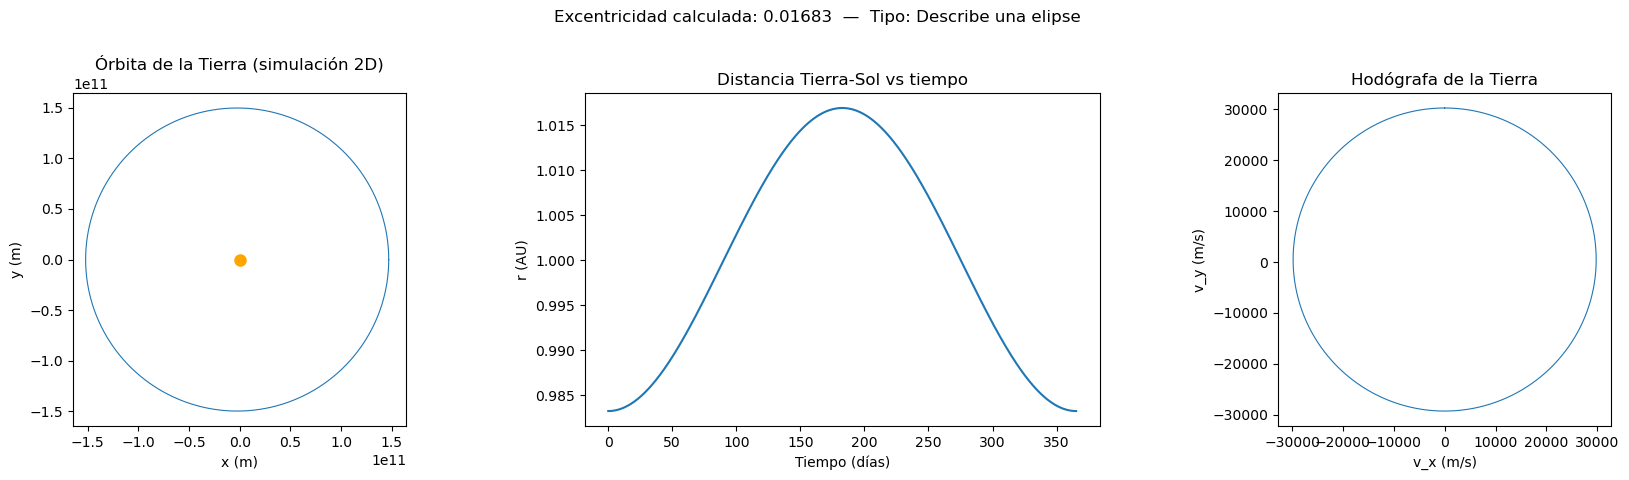

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------
# CONSTANTES FÍSICAS REALES
# -----------------------
G = 6.67430e-11          # m^3 kg^-1 s^-2
M = 1.9885e30            # masa del Sol (kg)

# -----------------------
# CONDICIONES INICIALES DE LA TIERRA
# -----------------------
r0 = 147.09e9            # perihelio en metros
v0 = 30290.0             # m/s velocidad en perihelio
Y0 = np.array([r0, 0.0, 0.0, v0], dtype=float)

# -----------------------
# PARÁMETROS DE SIMULACIÓN
# -----------------------
dt = 3600.0               # paso: 1 hora
seconds_per_year = 365.25 * 24 * 3600
n_steps = int(seconds_per_year // dt)  # simular ~1 año

# listas para guardar resultados
x_lista = [Y0[0]]
y_lista = [Y0[1]]
vx_lista = [Y0[2]]
vy_lista = [Y0[3]]
t = 0.0
Y = Y0.copy()

# integración RK4
for i in range(n_steps):
    Y = RK4_vec(func, dt, Y, t, G, M)
    t += dt
    x_lista.append(Y[0])
    y_lista.append(Y[1])
    vx_lista.append(Y[2])
    vy_lista.append(Y[3])

# -----------------------
# CÁLCULO DE LA EXCENTRICIDAD USANDO TUS FUNCIONES
# -----------------------
r_final = np.array([x_lista[-1], y_lista[-1]])
v_final = np.array([vx_lista[-1], vy_lista[-1]])

e_vec = excentricidad_vector(r_final, v_final, M)
e_num = np.linalg.norm(e_vec)
tipo = excentricidad(r_final, v_final, M)

print("Vector de excentricidad (2D) =", e_vec)
print("Excentricidad numérica =", e_num)
print("Tipo de órbita:", tipo)

# -----------------------
# GRÁFICAS
# -----------------------
fig, axs = plt.subplots(1, 3, figsize=(18,5))

# 1) Órbita 2D
axs[0].plot(0, 0, 'o', color='orange', markersize=8, label='Sol')
axs[0].plot(x_lista, y_lista, '-', linewidth=0.8)
axs[0].set_aspect('equal')
axs[0].set_title('Órbita de la Tierra (simulación 2D)')
axs[0].set_xlabel('x (m)')
axs[0].set_ylabel('y (m)')
AU = 1.495978707e11
axs[0].set_xlim(-1.1*AU, 1.1*AU)
axs[0].set_ylim(-1.1*AU, 1.1*AU)

# 2) Distancia al Sol vs tiempo
r_lista = np.sqrt(np.array(x_lista)**2 + np.array(y_lista)**2)
time_days = np.arange(len(r_lista)) * (dt/3600/24)
axs[1].plot(time_days, r_lista / AU)
axs[1].set_title('Distancia Tierra-Sol vs tiempo')
axs[1].set_xlabel('Tiempo (días)')
axs[1].set_ylabel('r (AU)')

# 3) Hodógrafa (v_x vs v_y)
axs[2].plot(vx_lista, vy_lista, '-', linewidth=0.8)
axs[2].set_aspect('equal')
axs[2].set_title('Hodógrafa de la Tierra')
axs[2].set_xlabel('v_x (m/s)')
axs[2].set_ylabel('v_y (m/s)')

plt.suptitle(f"Excentricidad calculada: {e_num:.5f}  —  Tipo: {tipo}")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### Datos de la tierra

In [20]:
x = np.array(x_lista)
y = np.array(y_lista)
vx = np.array(vx_lista)
vy = np.array(vy_lista)

r_vals = np.sqrt(x**2 + y**2)

i_peri = np.argmin(r_vals)
i_afel = np.argmax(r_vals)

r_peri = np.array([x[i_peri], y[i_peri]])
v_peri = np.array([vx[i_peri], vy[i_peri]])

r_afel = np.array([x[i_afel], y[i_afel]])
v_afel = np.array([vx[i_afel], vy[i_afel]])

E_peri = energia_total(r_peri, v_peri, M)
E_afel = energia_total(r_afel, v_afel, M)


print("ENERGÍA MECÁNICA")
print("----------------")
print(f"Perihelio:")
print(f"  r = {np.linalg.norm(r_peri)/AU:.6f} AU")
print(f"  E = {E_peri:.3e} J")

print(f"\nAfelio:")
print(f"  r = {np.linalg.norm(r_afel)/AU:.6f} AU")
print(f"  E = {E_afel:.3e} J")

print(f"\nDiferencia |E_peri - E_afel| = {abs(E_peri - E_afel):.3e} J")


print()
print()

# vector excentricidad en perihelio
e_peri = excentricidad_vector(r_peri, v_peri, M)
e_peri_mod = np.linalg.norm(e_peri)

# vector excentricidad en afelio
e_afel = excentricidad_vector(r_afel, v_afel, M)
e_afel_mod = np.linalg.norm(e_afel)

print("VECTOR DE EXCENTRICIDAD")
print("----------------------")
print("Perihelio:")
print("  e_vec =", e_peri)
print(f"  |e|   = {e_peri_mod:.8f}")

print("\nAfelio:")
print("  e_vec =", e_afel)
print(f"  |e|   = {e_afel_mod:.8f}")

print("\nDiferencias numéricas:")
print("  |e_peri - e_afel| =", np.linalg.norm(e_peri - e_afel))


ENERGÍA MECÁNICA
----------------
Perihelio:
  r = 0.983236 AU
  E = -4.436e+08 J

Afelio:
  r = 1.016908 AU
  E = -4.436e+08 J

Diferencia |E_peri - E_afel| = 6.258e-06 J


VECTOR DE EXCENTRICIDAD
----------------------
Perihelio:
  e_vec = [0.01683474 0.        ]
  |e|   = 0.01683474

Afelio:
  e_vec = [ 1.68347406e-02 -6.48743212e-15]
  |e|   = 0.01683474

Diferencias numéricas:
  |e_peri - e_afel| = 7.619790602965845e-15
